# Scene Classification Using CNNs and Transfer Learning
### 6CS012 – Artificial Intelligence and Machine Learning | Herald College Kathmandu

| | |
|---|---|
| **Student** | Binaya Bohara |
| **University ID** | 2418248 |
| **Module** | 6CS012 – AI |
| **Part** | II – Vision Task |
| **Dataset** | Intel Image Classification (6 classes, ~17 K images) |

---



In [1]:
#  0.1  Colab-only: mount Drive & install extras
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

#  0.2  Core imports ─
import random, time, zipfile, pathlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, mixed_precision
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

#  0.3  Reproducibility seed ─
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

#  0.4  GPU / device report
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {len(gpus)}")
if gpus:
    for g in gpus:
        print(f"  → {g}")
    # Enable mixed-precision (FP16) for ~2× throughput on T4/A100
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision    : float16 (enabled)")
else:
    print("WARNING: No GPU detected. Training will be slow.")
    print("Runtime → Change runtime type → GPU")

Mounted at /content/drive
TensorFlow version : 2.20.0
GPUs available     : 1
  → PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Mixed precision    : float16 (enabled)


In [9]:
#  0.5  Dataset paths – MODIFY THESE PATHS BASED ON YOUR SETUP ─
if IN_COLAB:
    # Option A: uploaded directly to Colab session
    BASE_DIR = '/content/Scene Classification'
    ZIP_PATH = '/content/Scene Classification.zip'

    # If zip not yet extracted:
    if not os.path.isdir(BASE_DIR) and os.path.isfile(ZIP_PATH):
        print("Extracting zip...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall('/content/')
        print("Done.")
else:
    # Local path – update as needed
    BASE_DIR = './Scene Classification'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

print(f"Dataset base directory : {BASE_DIR}")
print(f"Train directory exists : {os.path.exists(TRAIN_DIR)}")
print(f"Test directory exists  : {os.path.exists(TEST_DIR)}")

Extracting zip...
Done.
Dataset base directory : /content/Scene Classification
Train directory exists : True
Test directory exists  : True


---
## §1 · Data Understanding, Analysis, Visualisation & Cleaning
> **PDF §2.5.5** – *"Analyse and understand the dataset… distribution of images across different classes… preprocessing techniques… data augmentation visualisations."*

In [10]:
#  1.1  Identify and remove corrupt files (≤ 10 bytes) ─
# Proposal §3.1: "A small number of corrupt files (~10 bytes) were identified"

def find_corrupt(root, min_bytes=100):
    """Return list of corrupt image paths (too small or unreadable)."""
    corrupt = []
    for p in pathlib.Path(root).rglob('*.jpg'):
        if p.stat().st_size < min_bytes:
            corrupt.append(str(p))
            continue
        try:
            Image.open(p).verify()
        except (UnidentifiedImageError, Exception):
            corrupt.append(str(p))
    return corrupt

print("Scanning for corrupt images...")
corrupt_train = find_corrupt(TRAIN_DIR)
corrupt_test  = find_corrupt(TEST_DIR)
print(f"Corrupt images in train : {len(corrupt_train)}")
print(f"Corrupt images in test  : {len(corrupt_test)}")

# Remove corrupt files so generators never see them
for p in corrupt_train + corrupt_test:
    os.remove(p)
    print(f"  Removed: {p}")
print("Corrupt files removed.")

Scanning for corrupt images...
Corrupt images in train : 42
Corrupt images in test  : 0
  Removed: /content/Scene Classification/train/forest/7595.jpg
  Removed: /content/Scene Classification/train/forest/8162.jpg
  Removed: /content/Scene Classification/train/forest/134.jpg
  Removed: /content/Scene Classification/train/forest/5818.jpg
  Removed: /content/Scene Classification/train/forest/1554.jpg
  Removed: /content/Scene Classification/train/forest/6746.jpg
  Removed: /content/Scene Classification/train/forest/11977.jpg
  Removed: /content/Scene Classification/train/sea/6369.jpg
  Removed: /content/Scene Classification/train/sea/916.jpg
  Removed: /content/Scene Classification/train/sea/3041.jpg
  Removed: /content/Scene Classification/train/sea/17040.jpg
  Removed: /content/Scene Classification/train/sea/10948.jpg
  Removed: /content/Scene Classification/train/sea/13762.jpg
  Removed: /content/Scene Classification/train/sea/4578.jpg
  Removed: /content/Scene Classification/train/bu

Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Class distribution:
Class           Train     Test    Total
----------------------------------------
buildings        2184      437     2621
forest           2264      474     2738
glacier          2397      553     2950
mountain         2505      525     3030
sea              2267      510     2777
street           2375      501     2876
TOTAL           13992     3000    16992


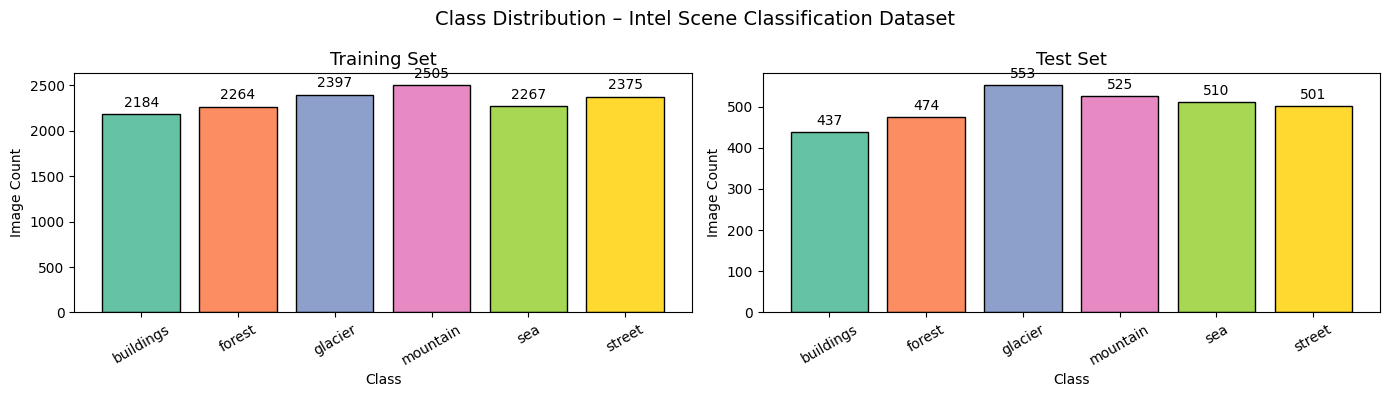


Observation: Dataset is nearly balanced (max imbalance ~15%). Standard accuracy is a valid primary metric (Proposal §4.1).


In [11]:
#  1.2  Class distribution ─
CLASSES = sorted(os.listdir(TRAIN_DIR))
N_CLASSES = len(CLASSES)
print(f"Classes ({N_CLASSES}): {CLASSES}")

train_counts = {c: len(list(pathlib.Path(TRAIN_DIR, c).glob('*.jpg'))) for c in CLASSES}
test_counts  = {c: len(list(pathlib.Path(TEST_DIR,  c).glob('*.jpg'))) for c in CLASSES}

print("\nClass distribution:")
print(f"{'Class':<12} {'Train':>8} {'Test':>8} {'Total':>8}")
print("-" * 40)
for c in CLASSES:
    print(f"{c:<12} {train_counts[c]:>8} {test_counts[c]:>8} {train_counts[c]+test_counts[c]:>8}")
print(f"{'TOTAL':<12} {sum(train_counts.values()):>8} {sum(test_counts.values()):>8} "
      f"{sum(train_counts.values())+sum(test_counts.values()):>8}")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Training Set', 'Test Set']):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=plt.cm.Set2.colors[:N_CLASSES], edgecolor='black')
    ax.bar_label(bars, padding=3)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Image Count')
    ax.set_xlabel('Class')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Class Distribution – Intel Scene Classification Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nObservation: Dataset is nearly balanced (max imbalance ~15%). "
      "Standard accuracy is a valid primary metric (Proposal §4.1).")

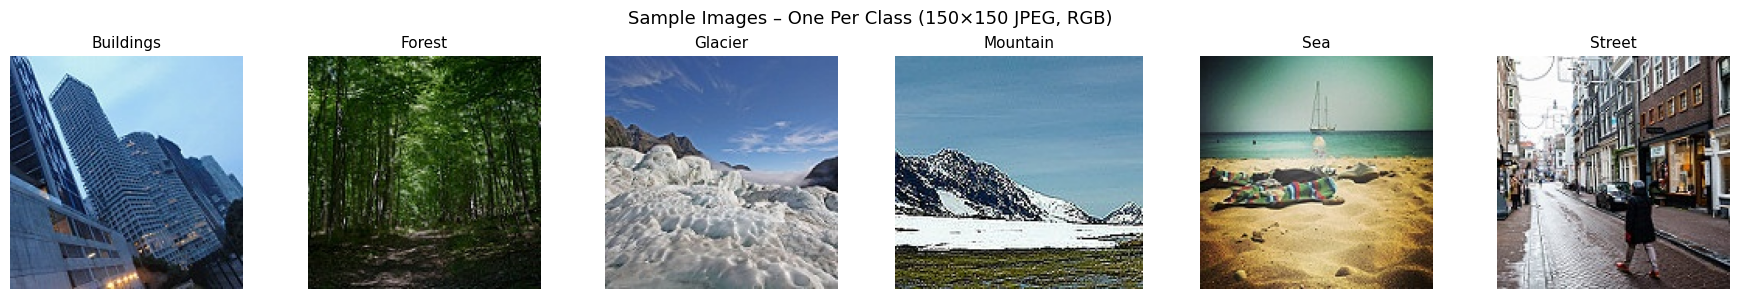

Sample image size   : (150, 150)  mode: RGB
Native resolution   : ~150×150 px (Proposal §3.3)
Part A will use 150×150; Part B will resize to 224×224 for VGG16.


In [12]:
#  1.3  Sample image grid (one per class)
fig, axes = plt.subplots(1, N_CLASSES, figsize=(18, 3))
for ax, cls in zip(axes, CLASSES):
    imgs = list(pathlib.Path(TRAIN_DIR, cls).glob('*.jpg'))
    img  = Image.open(random.choice(imgs)).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls.capitalize(), fontsize=11)
    ax.axis('off')
plt.suptitle('Sample Images – One Per Class (150×150 JPEG, RGB)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

# Image resolution check
sample_path = random.choice(list(pathlib.Path(TRAIN_DIR, CLASSES[0]).glob('*.jpg')))
sample_img  = Image.open(sample_path)
print(f"Sample image size   : {sample_img.size}  mode: {sample_img.mode}")
print(f"Native resolution   : ~150×150 px (Proposal §3.3)")
print("Part A will use 150×150; Part B will resize to 224×224 for VGG16.")

In [13]:
#  1.4  Data generators – Part A (150×150) ─
# PDF §2.5.1: "preprocessing techniques… data augmentation… visualisations"
# Proposal §5.1: Augmentation only on train; 80/20 validation split

IMG_SIZE_A = (150, 150)
BATCH_SIZE = 32   # Colab T4: 32 keeps VRAM usage comfortable
VAL_SPLIT  = 0.20

train_aug_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.15,
    height_shift_range=0.15,
)
val_gen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)
test_gen_A = ImageDataGenerator(rescale=1./255)

train_ds = train_aug_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_A, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)
val_ds = val_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_A, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)
test_ds_A = test_gen_A.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_A, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_INDICES = train_ds.class_indices
IDX_TO_CLASS  = {v: k for k, v in CLASS_INDICES.items()}
print(f"\nClass → index mapping: {CLASS_INDICES}")
print(f"Train batches: {len(train_ds)}  |  Val batches: {len(val_ds)}  |  Test batches: {len(test_ds_A)}")

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

Class → index mapping: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Train batches: 350  |  Val batches: 88  |  Test batches: 94


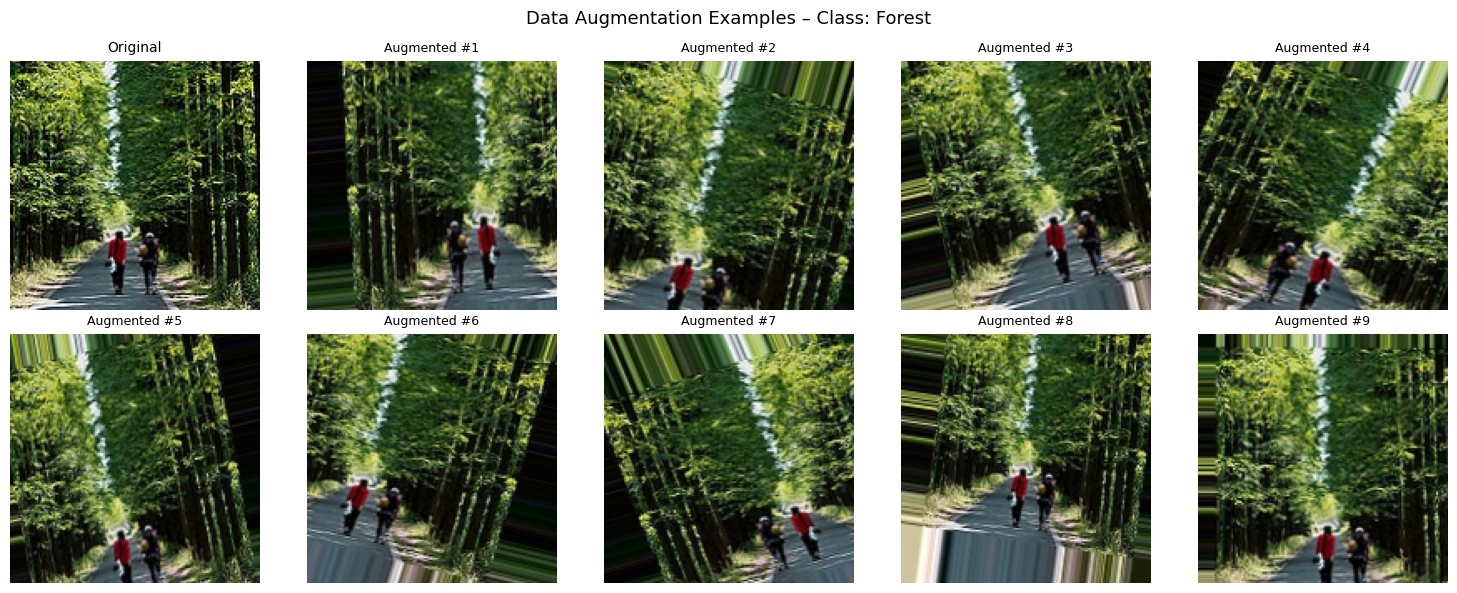

Techniques: horizontal_flip | rotation_range=20 | zoom_range=0.20 | width/height_shift=0.15


In [14]:
#  1.5  Augmentation visualisation ─
# PDF §2.5.1: "If data augmentation was applied, provide visualisations"

aug_only = ImageDataGenerator(
    horizontal_flip=True, rotation_range=20,
    zoom_range=0.20, width_shift_range=0.15, height_shift_range=0.15
)

sample_cls  = CLASSES[1]  # Forest
sample_imgs = list(pathlib.Path(TRAIN_DIR, sample_cls).glob('*.jpg'))[:1]
orig = np.array(Image.open(sample_imgs[0]).resize(IMG_SIZE_A)) / 255.
img4d = orig[np.newaxis, ...]          # shape (1, H, W, 3)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(orig)
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

aug_iter = aug_only.flow(img4d, batch_size=1, seed=SEED)
for i, ax in enumerate(axes.flat[1:]):
    aug_img = next(aug_iter)[0]
    ax.imshow(np.clip(aug_img, 0, 1))
    ax.set_title(f'Augmented #{i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Data Augmentation Examples – Class: {sample_cls.capitalize()}', fontsize=13)
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print("Techniques: horizontal_flip | rotation_range=20 | zoom_range=0.20 | "
      "width/height_shift=0.15")

---
## §2 · Part A – Baseline CNN (Trained from Scratch)
> **PDF §2.5.2** – *"Build a baseline CNN with three Conv layers + pooling, three FCN layers, output layer."*

In [15]:
#  2.1  Baseline architecture
# PDF §2.5.2: 3 Conv+Pool | 3 FCN | softmax output
# Proposal §5.2: filters 32, 64, 128 | ReLU | MaxPool

def build_baseline(input_shape=(150, 150, 3), n_classes=6):
    """Baseline CNN: 3× [Conv2D → MaxPool2D] then 3× Dense → Softmax."""
    model = models.Sequential(name='Baseline_CNN')

    #  Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    #  Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    #  Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    #  FCN head (3 dense layers)
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64,  activation='relu'))

    #  Output (6-class softmax)
    model.add(layers.Dense(n_classes, activation='softmax', dtype='float32'))
    return model

baseline_model = build_baseline()
baseline_model.summary()

print("\n[Architecture notes]")
print("  Kernel size     : 3×3 (standard – large receptive field with few params)")
print("  Filters         : 32 → 64 → 128 (doubling pattern, standard practice)")
print("  Activation      : ReLU (non-vanishing for ReLU activations)")
print("  Pooling         : MaxPool 2×2 (spatial downsampling, translation invariance)")
print("  Output dtype    : float32 (required when mixed_precision is active)")

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,751,878 (41.02 MB)

 Trainable params: 10,751,878 (41.02 MB)

 Non-trainable params: 0 (0.00 B)


[Architecture notes]
  Kernel size     : 3×3 (standard – large receptive field with few params)
  Filters         : 32 → 64 → 128 (doubling pattern, standard practice)
  Activation      : ReLU (non-vanishing for ReLU activations)
  Pooling         : MaxPool 2×2 (spatial downsampling, translation invariance)
  Output dtype    : float32 (required when mixed_precision is active)


In [16]:
#  2.2  Compile & train baseline
# PDF §2.5.2: "Train for an appropriate number of epochs; plot training vs val loss"

baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
lr_reduce = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

t0 = time.time()
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)
baseline_train_time = time.time() - t0
print(f"\nBaseline training time: {baseline_train_time:.1f} s")

Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 108s 255ms/step - accuracy: 0.5677 - loss: 1.0849 - val_accuracy: 0.6842 - val_loss: 0.8120 - learning_rate: 0.0010
Epoch 2/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 72s 206ms/step - accuracy: 0.6758 - loss: 0.8528 - val_accuracy: 0.7357 - val_loss: 0.7334 - learning_rate: 0.0010
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 204ms/step - accuracy: 0.7400 - loss: 0.7078 - val_accuracy: 0.8036 - val_loss: 0.5483 - learning_rate: 0.0010
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 72s 206ms/step - accuracy: 0.7612 - loss: 0.6479 - val_accuracy: 0.8001 - val_loss: 0.5626 - learning_rate: 0.0010
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 203ms/step - accuracy: 0.7794 - loss: 0.6077 - val_accuracy: 0.7933 - val_loss: 0.5983 - learning_rate: 0.0010
Epoch 6/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 72s 207ms/step - accuracy: 0.7994 - loss: 0.5559 - val_accuracy: 0.8244 - val_loss: 0.4807 - learning_rate: 0.0010
Epoch 7/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 221ms/step - accuracy: 0.

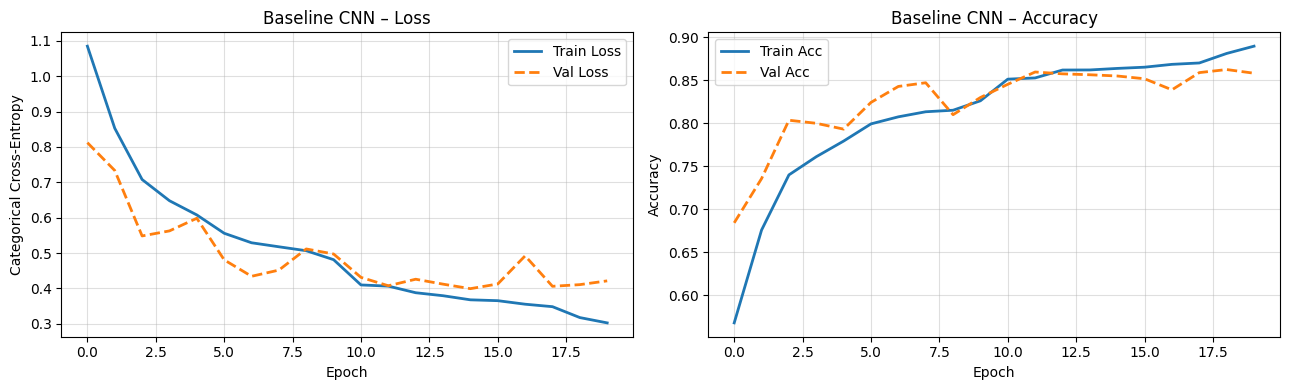

In [17]:
#  2.3  Loss & accuracy curves helper

def plot_history(history, title='Model', save_name=None):
    """Plot training vs validation loss and accuracy."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(history.history['loss'],     label='Train Loss',  linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss',    linewidth=2, linestyle='--')
    ax1.set_title(f'{title} – Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Categorical Cross-Entropy')
    ax1.legend()
    ax1.grid(True, alpha=0.4)

    ax2.plot(history.history['accuracy'],     label='Train Acc',  linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
    ax2.set_title(f'{title} – Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.4)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, title='Baseline CNN',
             save_name='baseline_curves.png')


  Baseline CNN – Evaluation Results
  Test Loss     : 0.4047
  Test Accuracy : 0.8613 (86.13%)

Classification Report:
              precision    recall  f1-score   support

   buildings     0.8158    0.9222    0.8657       437
      forest     0.9564    0.9726    0.9644       474
     glacier     0.8374    0.8101    0.8235       553
    mountain     0.8214    0.7448    0.7812       525
         sea     0.8505    0.8588    0.8546       510
      street     0.8896    0.8842    0.8869       501

    accuracy                         0.8613      3000
   macro avg     0.8618    0.8655    0.8627      3000
weighted avg     0.8612    0.8613    0.8604      3000



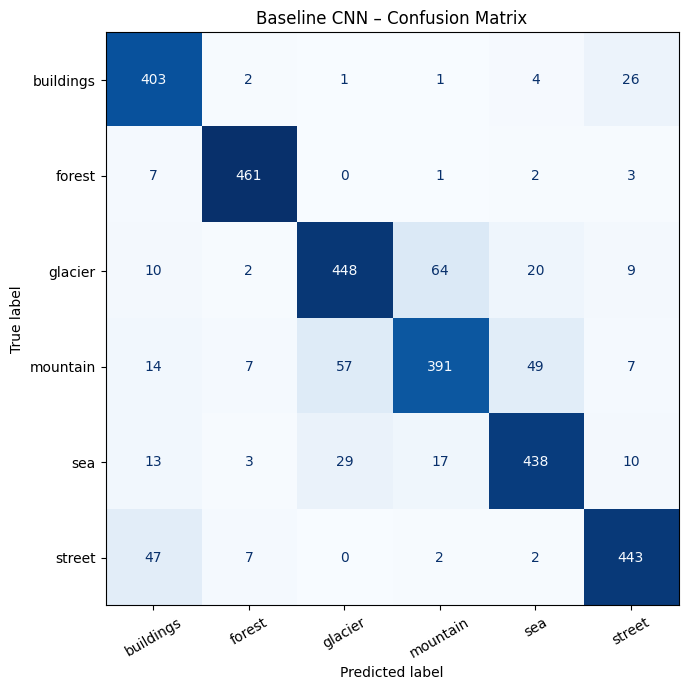

In [18]:
#  2.4  Evaluation helper ─
# PDF §2.5.2: "accuracy, precision, recall and F1-score; inference on sample images"

def evaluate_model(model, test_generator, model_name='Model'):
    """Full evaluation: accuracy, classification report, confusion matrix."""
    test_generator.reset()
    y_pred_proba = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = test_generator.classes
    class_names = list(IDX_TO_CLASS[i] for i in range(N_CLASSES))

    print(f"\n{'='*55}")
    print(f"  {model_name} – Evaluation Results")
    print(f"{'='*55}")

    # Loss + accuracy from Keras
    test_generator.reset()
    loss, acc = model.evaluate(test_generator, verbose=0)
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")

    # Classification report (precision, recall, F1)
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} – Confusion Matrix')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f'confusion_{model_name.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

    return {'name': model_name, 'loss': loss, 'accuracy': acc,
            'y_pred': y_pred, 'y_true': y_true, 'class_names': class_names}

baseline_results = evaluate_model(baseline_model, test_ds_A, 'Baseline CNN')

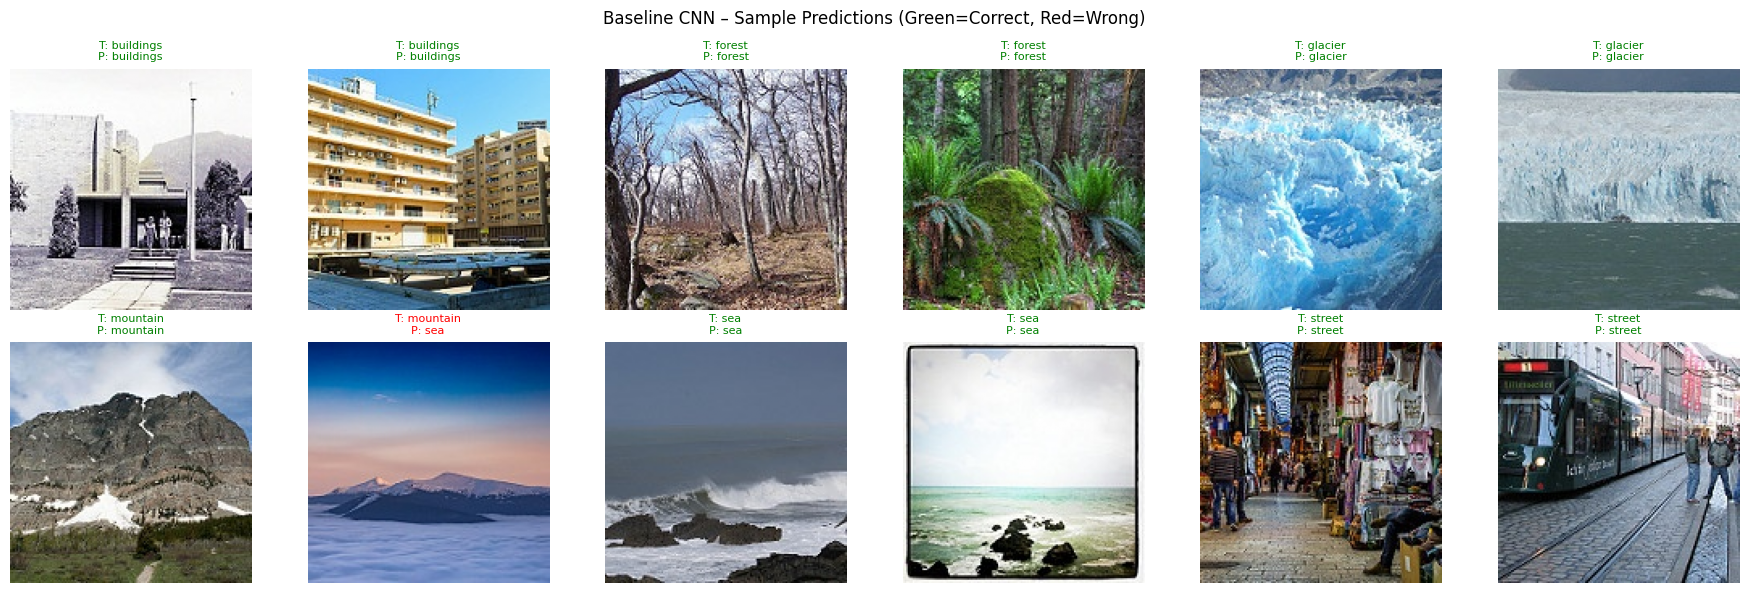

In [25]:
#  2.5  Inference on sample test images
# PDF §2.5.2: "Perform inference on sample images and plot the result"

def show_predictions(model, test_dir, n=12, img_size=IMG_SIZE_A, title='Baseline'):
    """Show grid of test images with true vs predicted labels."""
    samples, true_labels = [], []
    for cls in CLASSES:
        imgs = list(pathlib.Path(test_dir, cls).glob('*.jpg'))[:2]
        for p in imgs:
            samples.append(str(p))
            true_labels.append(cls)

    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    for ax, path, true in zip(axes.flat, samples, true_labels):
        img = Image.open(path).resize(img_size).convert('RGB')
        arr = np.array(img) / 255.
        pred_idx  = np.argmax(model.predict(arr[np.newaxis], verbose=0))
        pred_cls  = IDX_TO_CLASS[pred_idx]
        correct   = pred_cls == true
        ax.imshow(arr)
        ax.set_title(f'T: {true}\nP: {pred_cls}',
                     color='green' if correct else 'red', fontsize=8)
        ax.axis('off')
    plt.suptitle(f'{title} – Sample Predictions (Green=Correct, Red=Wrong)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'predictions_{title.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

show_predictions(baseline_model, TEST_DIR, title='Baseline CNN')

---
## §3 · Part A – Deeper CNN with Regularisation
> **PDF §2.5.3** – *"At least double the layers vs baseline; add BatchNorm and Dropout."*

In [20]:
#  3.1  Deeper architecture
# Proposal §5.2: Deeper = 6+ conv layers, BatchNorm, Dropout(0.5)
# PDF §2.5.3: "at least double the layers compared to baseline"

def build_deeper(input_shape=(150, 150, 3), n_classes=6, dropout_rate=0.5):
    """Deeper CNN: 6× Conv blocks w/ BatchNorm, Dropout, 3-layer FCN head."""
    model = models.Sequential(name='Deeper_CNN')

    #  Block 1  (2 conv)
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    #  Block 2  (2 conv)
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    #  Block 3  (2 conv)
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    #  FCN head
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(128, activation='relu'))

    #  Output
    model.add(layers.Dense(n_classes, activation='softmax', dtype='float32'))
    return model

deeper_model = build_deeper()
deeper_model.summary()
print("\n[Regularisation notes]")
print("  BatchNormalization : Stabilises activations, speeds up training")
print("  Dropout(0.25)      : Light regularisation after each conv block")
print("  Dropout(0.5)       : Heavy regularisation in FCN head")

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 21,690,022 (82.74 MB)

 Trainable params: 21,688,102 (82.73 MB)

 Non-trainable params: 1,920 (7.50 KB)


[Regularisation notes]
  BatchNormalization : Stabilises activations, speeds up training
  Dropout(0.25)      : Light regularisation after each conv block
  Dropout(0.5)       : Heavy regularisation in FCN head


Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 142s 324ms/step - accuracy: 0.5090 - loss: 1.2731 - val_accuracy: 0.1634 - val_loss: 4.2884 - learning_rate: 0.0010
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 84s 240ms/step - accuracy: 0.6300 - loss: 0.9649 - val_accuracy: 0.7371 - val_loss: 0.7072 - learning_rate: 0.0010
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6935 - loss: 0.8358
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
350/350 ━━━━━━━━━━━━━━━━━━━━ 82s 235ms/step - accuracy: 0.7036 - loss: 0.8095 - val_accuracy: 0.7454 - val_loss: 0.6834 - learning_rate: 0.0010
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 82s 234ms/step - accuracy: 0.7437 - loss: 0.6976 - val_accuracy: 0.6681 - val_loss: 0.9727 - learning_rate: 5.0000e-04
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 80s 229ms/step - accuracy: 0.7616 - loss: 0.6606 - val_accuracy: 0.7539 - val_loss: 0.6593 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of

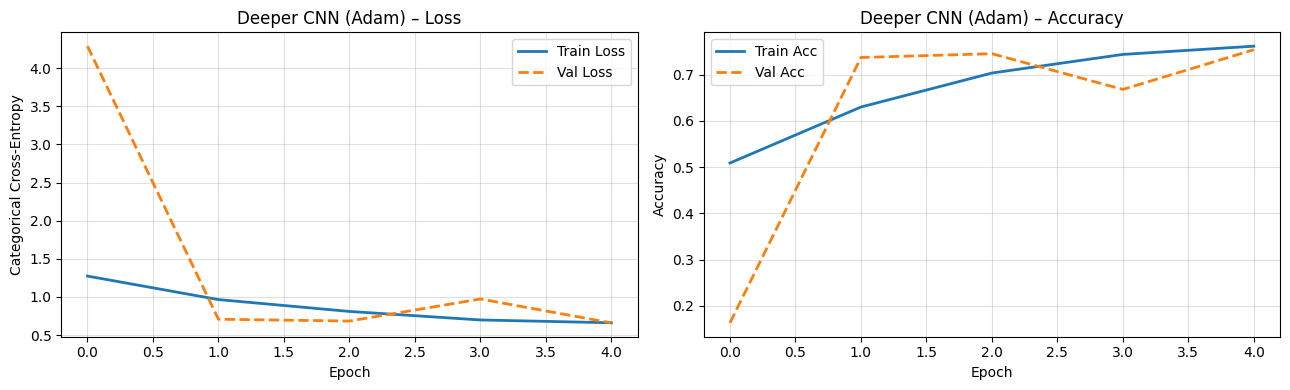


  Deeper CNN – Adam – Evaluation Results
  Test Loss     : 4.1825
  Test Accuracy : 0.1707 (17.07%)

Classification Report:
              precision    recall  f1-score   support

   buildings     0.3333    0.0023    0.0045       437
      forest     1.0000    0.0021    0.0042       474
     glacier     0.0000    0.0000    0.0000       553
    mountain     0.0000    0.0000    0.0000       525
         sea     0.1764    1.0000    0.2999       510
      street     0.0000    0.0000    0.0000       501

    accuracy                         0.1707      3000
   macro avg     0.2516    0.1674    0.0514      3000
weighted avg     0.2365    0.1707    0.0523      3000



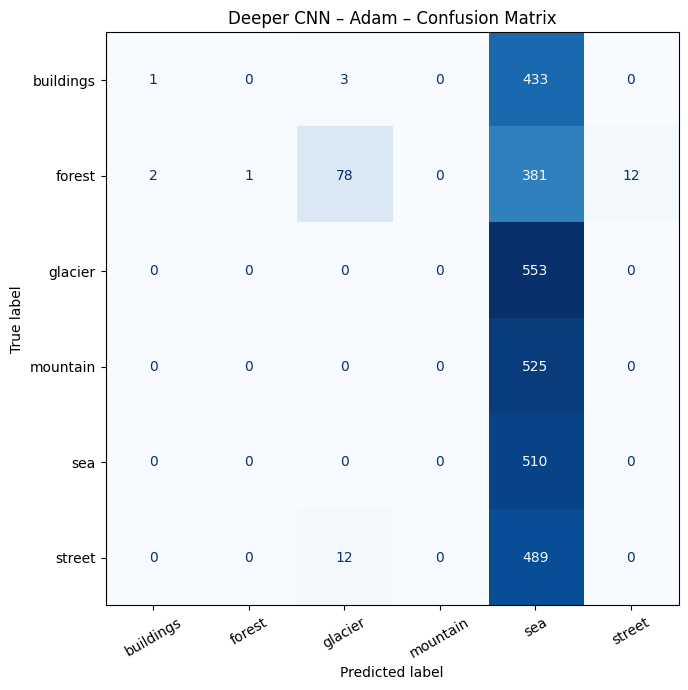

In [21]:
#  3.2  Train Deeper model with Adam
# PDF §2.5.4: "Optimizer Analysis: SGD vs Adam"

deeper_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_deeper_adam = deeper_model.fit(
    train_ds, validation_data=val_ds, epochs=40,
    callbacks=[early_stop, lr_reduce], verbose=1
)
deeper_adam_time = time.time() - t0
print(f"\nDeeper-Adam training time: {deeper_adam_time:.1f} s")

plot_history(history_deeper_adam, title='Deeper CNN (Adam)',
             save_name='deeper_adam_curves.png')
deeper_adam_results = evaluate_model(deeper_model, test_ds_A, 'Deeper CNN – Adam')

Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 105s 261ms/step - accuracy: 0.4785 - loss: 1.3508 - val_accuracy: 0.5733 - val_loss: 1.0301 - learning_rate: 0.0100
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 79s 227ms/step - accuracy: 0.5748 - loss: 1.0722 - val_accuracy: 0.5951 - val_loss: 1.0209 - learning_rate: 0.0100
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.6200 - loss: 0.9841
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
350/350 ━━━━━━━━━━━━━━━━━━━━ 80s 229ms/step - accuracy: 0.6217 - loss: 0.9825 - val_accuracy: 0.7017 - val_loss: 0.7817 - learning_rate: 0.0100
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 78s 223ms/step - accuracy: 0.6777 - loss: 0.8595 - val_accuracy: 0.7300 - val_loss: 0.6809 - learning_rate: 0.0050
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 80s 229ms/step - accuracy: 0.6993 - loss: 0.8063 - val_accuracy: 0.7285 - val_loss: 0.7468 - learning_rate: 0.0050
Epoch 5: early stopping
Restoring model weights from the end of the best

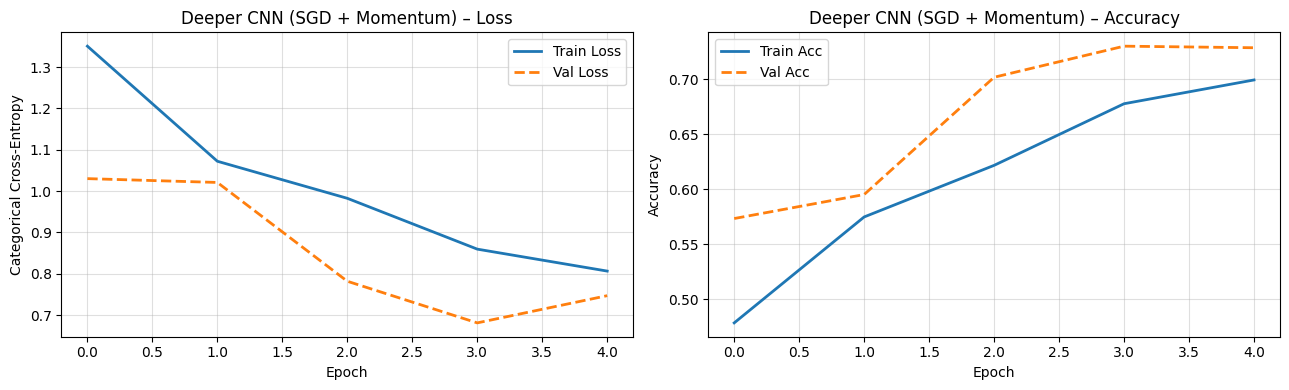


  Deeper CNN – SGD – Evaluation Results
  Test Loss     : 1.0007
  Test Accuracy : 0.5877 (58.77%)

Classification Report:
              precision    recall  f1-score   support

   buildings     0.5587    0.4897    0.5220       437
      forest     0.7280    0.9093    0.8086       474
     glacier     0.5433    0.4195    0.4735       553
    mountain     0.7151    0.4971    0.5865       525
         sea     0.3840    0.6392    0.4798       510
      street     0.7786    0.5968    0.6757       501

    accuracy                         0.5877      3000
   macro avg     0.6180    0.5919    0.5910      3000
weighted avg     0.6170    0.5877    0.5881      3000



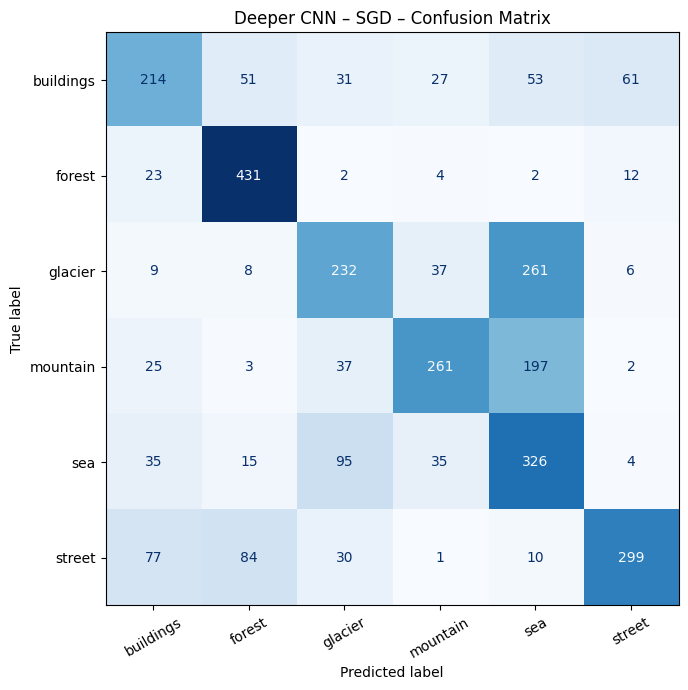

In [22]:
#  3.3  Re-train Deeper model with SGD ─
# PDF §2.5.4: "Train deeper model with SGD then Adam; compare convergence"

deeper_sgd_model = build_deeper()
deeper_sgd_model.compile(
    optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_deeper_sgd = deeper_sgd_model.fit(
    train_ds, validation_data=val_ds, epochs=40,
    callbacks=[early_stop, lr_reduce], verbose=1
)
deeper_sgd_time = time.time() - t0
print(f"\nDeeper-SGD training time: {deeper_sgd_time:.1f} s")

plot_history(history_deeper_sgd, title='Deeper CNN (SGD + Momentum)',
             save_name='deeper_sgd_curves.png')
deeper_sgd_results = evaluate_model(deeper_sgd_model, test_ds_A, 'Deeper CNN – SGD')

Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 113s 279ms/step - accuracy: 0.5928 - loss: 1.0481 - val_accuracy: 0.1810 - val_loss: 3.4180 - learning_rate: 0.0010
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 221ms/step - accuracy: 0.7057 - loss: 0.7791 - val_accuracy: 0.6692 - val_loss: 0.8328 - learning_rate: 0.0010
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7369 - loss: 0.6983
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
350/350 ━━━━━━━━━━━━━━━━━━━━ 78s 222ms/step - accuracy: 0.7453 - loss: 0.6877 - val_accuracy: 0.6513 - val_loss: 1.0324 - learning_rate: 0.0010
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 78s 221ms/step - accuracy: 0.7907 - loss: 0.5723 - val_accuracy: 0.7246 - val_loss: 0.7440 - learning_rate: 5.0000e-04
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 80s 228ms/step - accuracy: 0.8005 - loss: 0.5434 - val_accuracy: 0.7325 - val_loss: 0.7762 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of

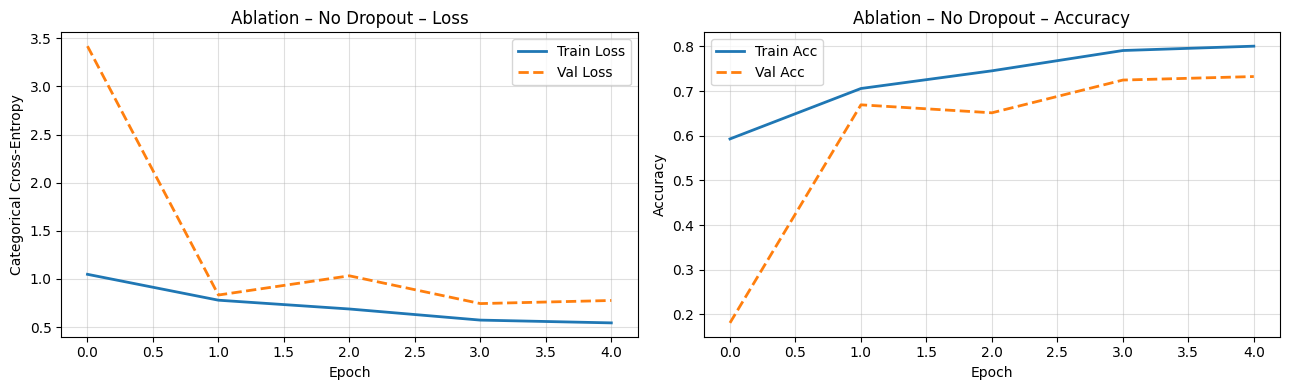


  Ablation – No Dropout – Evaluation Results
  Test Loss     : 3.3239
  Test Accuracy : 0.1920 (19.20%)

Classification Report:
              precision    recall  f1-score   support

   buildings     0.3333    0.0023    0.0045       437
      forest     0.0000    0.0000    0.0000       474
     glacier     0.1635    0.1392    0.1504       553
    mountain     0.0000    0.0000    0.0000       525
         sea     0.1979    0.9765    0.3290       510
      street     0.0000    0.0000    0.0000       501

    accuracy                         0.1920      3000
   macro avg     0.1158    0.1863    0.0807      3000
weighted avg     0.1123    0.1920    0.0843      3000



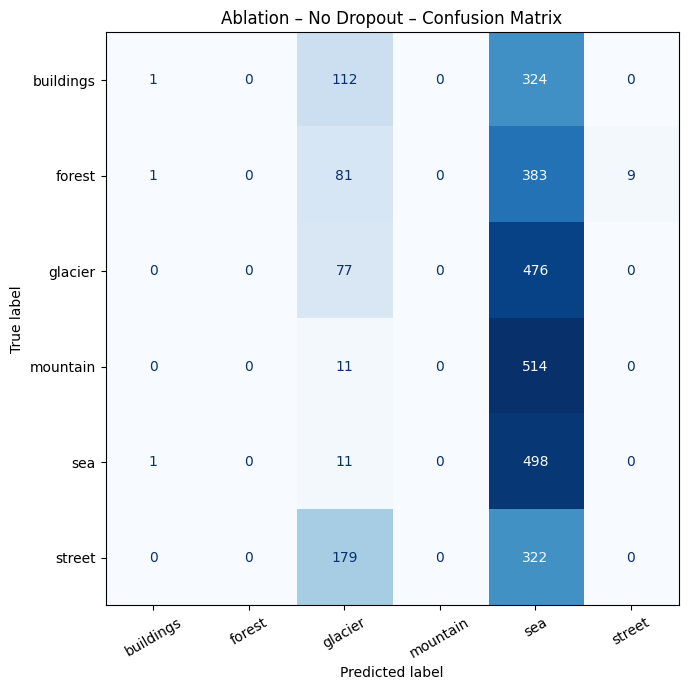


[Ablation interpretation]
  Compare val loss gap (train vs val) between Deeper+Dropout and Ablation.
  A larger gap in Ablation confirms Dropout's regularisation effect.


In [23]:
#  3.4  Ablation study: remove Dropout ─
# PDF §2.5.4: "Remove one component (e.g. dropout); analyse how performance changes"

ablation_model = build_deeper(dropout_rate=0.0)  # Dropout removed (rate=0)
ablation_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_ablation = ablation_model.fit(
    train_ds, validation_data=val_ds, epochs=40,
    callbacks=[early_stop, lr_reduce], verbose=1
)
ablation_time = time.time() - t0
print(f"\nAblation (no-Dropout) training time: {ablation_time:.1f} s")

plot_history(history_ablation, title='Ablation – No Dropout',
             save_name='ablation_curves.png')
ablation_results = evaluate_model(ablation_model, test_ds_A, 'Ablation – No Dropout')

print("\n[Ablation interpretation]")
print("  Compare val loss gap (train vs val) between Deeper+Dropout and Ablation.")
print("  A larger gap in Ablation confirms Dropout's regularisation effect.")

---
## §4 · Comparative Analysis
> **PDF §2.5.4** – *"Baseline vs Deeper; Computational Efficiency; Optimizer Analysis; Ablation Study."*

Model                    Test Acc  Test Loss  Train Time(s)
------------------------------------------------------------
Baseline CNN               0.8613     0.4047         1485.4
Deeper – Adam              0.1707     4.1825          471.3
Deeper – SGD               0.5877     1.0007          423.2
Ablation No-Drop           0.1920     3.3239          426.5


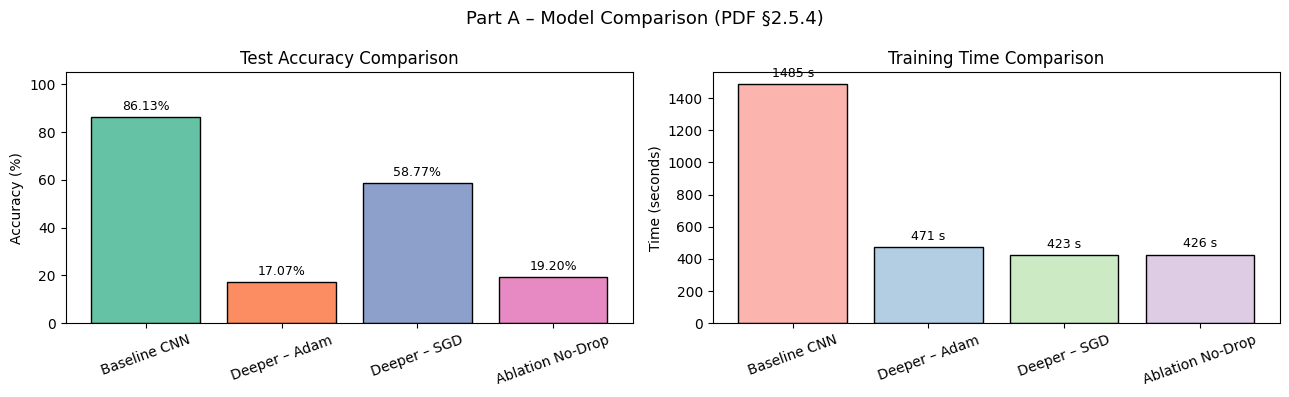

In [24]:
#  4.1  Summary comparison table

results_all = [
    ('Baseline CNN',       baseline_results,      baseline_train_time),
    ('Deeper – Adam',      deeper_adam_results,   deeper_adam_time),
    ('Deeper – SGD',       deeper_sgd_results,    deeper_sgd_time),
    ('Ablation No-Drop',   ablation_results,      ablation_time),
]

print(f"{'Model':<22} {'Test Acc':>10} {'Test Loss':>10} {'Train Time(s)':>14}")
print("-" * 60)
for name, res, t in results_all:
    print(f"{name:<22} {res['accuracy']:>10.4f} {res['loss']:>10.4f} {t:>14.1f}")

# Visual bar chart
names = [r[0] for r in results_all]
accs  = [r[1]['accuracy'] for r in results_all]
times = [r[2] for r in results_all]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
bars1 = ax1.bar(names, [a*100 for a in accs],
                color=plt.cm.Set2.colors[:4], edgecolor='black')
ax1.bar_label(bars1, fmt='%.2f%%', padding=3, fontsize=9)
ax1.set_title('Test Accuracy Comparison')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 105)
ax1.tick_params(axis='x', rotation=20)

bars2 = ax2.bar(names, times, color=plt.cm.Pastel1.colors[:4], edgecolor='black')
ax2.bar_label(bars2, fmt='%.0f s', padding=3, fontsize=9)
ax2.set_title('Training Time Comparison')
ax2.set_ylabel('Time (seconds)')
ax2.tick_params(axis='x', rotation=20)

plt.suptitle('Part A – Model Comparison (PDF §2.5.4)', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

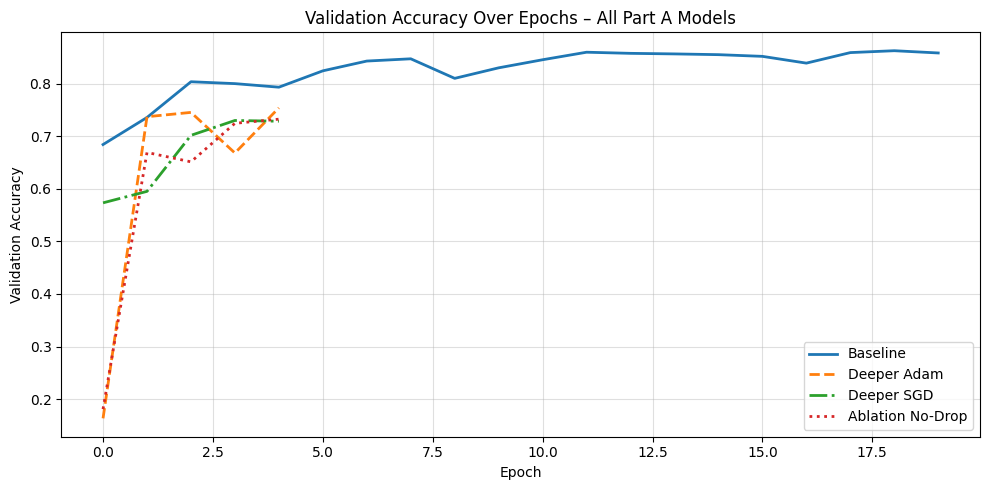

[Discussion points for report]
  1. Does Deeper Adam converge faster than Baseline?
  2. Does SGD converge more slowly but reach comparable final accuracy?
  3. Does removing Dropout cause higher train-val divergence?
  4. Is deeper always better? Consider training time trade-off.


In [31]:
#  4.2  Overlaid val-accuracy curves

fig, ax = plt.subplots(figsize=(10, 5))
for hist, label, ls in [
    (history_baseline,    'Baseline', '-'),
    (history_deeper_adam, 'Deeper Adam', '--'),
    (history_deeper_sgd,  'Deeper SGD',  '-.'),
    (history_ablation,    'Ablation No-Drop', ':'),
]:
    ax.plot(hist.history['val_accuracy'], label=label, linestyle=ls, linewidth=2)

ax.set_title('Validation Accuracy Over Epochs – All Part A Models')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('val_acc_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

print("[Discussion points for report]")
print("  1. Does Deeper Adam converge faster than Baseline?")
print("  2. Does SGD converge more slowly but reach comparable final accuracy?")
print("  3. Does removing Dropout cause higher train-val divergence?")
print("  4. Is deeper always better? Consider training time trade-off.")

---
## §5 · Part B – Transfer Learning with VGG16
> **PDF §2.6** – *"Load VGG16, remove FC head, add custom head; Feature Extraction then Fine-Tuning."*

In [26]:
#  5.1  Generators for 224×224 (VGG16 input size)
# PDF §2.6.2: "Resize dataset images to 224×224 for VGG, ResNet"
# Proposal §5.3: images resized using ImageDataGenerator

IMG_SIZE_B = (224, 224)
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

train_gen_B = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    validation_split=VAL_SPLIT,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.15,
    height_shift_range=0.15,
)
val_gen_B  = ImageDataGenerator(preprocessing_function=vgg_preprocess,
                                validation_split=VAL_SPLIT)
test_gen_B = ImageDataGenerator(preprocessing_function=vgg_preprocess)

train_ds_B = train_gen_B.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_B, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)
val_ds_B = val_gen_B.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_B, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)
test_ds_B = test_gen_B.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_B, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
print("VGG16 generators (224×224) ready.")
print(f"  Note: vgg_preprocess converts RGB → BGR, scales to ImageNet mean-centred.")

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
VGG16 generators (224×224) ready.
  Note: vgg_preprocess converts RGB → BGR, scales to ImageNet mean-centred.


In [27]:
#  5.2  Build VGG16 transfer learning model ─
# PDF §2.6.1: Remove original FC layers, add custom Dense head
# Proposal §5.3: Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(6, softmax)

base_vgg = VGG16(weights='imagenet', include_top=False,
                 input_shape=(224, 224, 3))

# Phase 1: Freeze entire base for feature extraction
base_vgg.trainable = False
print(f"VGG16 base loaded. Trainable params (frozen): 0")
print(f"Total base params: {base_vgg.count_params():,}")

# Custom classification head
inputs  = keras.Input(shape=(224, 224, 3))
x = base_vgg(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)     # More efficient than Flatten for large maps
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(N_CLASSES, activation='softmax', dtype='float32')(x)

vgg_model = keras.Model(inputs, outputs, name='VGG16_Transfer')
vgg_model.summary()

print("\n[Architecture decisions]")
print("  GlobalAveragePooling2D : Reduces spatial map to 512-d vector; fewer params than Flatten")
print("  Convolutional base     : Frozen (ImageNet weights preserved)")
print("  New head               : Dense(256) → Dropout(0.5) → Dense(6, softmax)")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base loaded. Trainable params (frozen): 0
Total base params: 14,714,688


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


[Architecture decisions]
  GlobalAveragePooling2D : Reduces spatial map to 512-d vector; fewer params than Flatten
  Convolutional base     : Frozen (ImageNet weights preserved)
  New head               : Dense(256) → Dropout(0.5) → Dense(6, softmax)


Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 184s 482ms/step - accuracy: 0.7958 - loss: 0.7288 - val_accuracy: 0.9027 - val_loss: 0.3309 - learning_rate: 0.0010
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 177s 451ms/step - accuracy: 0.8670 - loss: 0.3729 - val_accuracy: 0.9077 - val_loss: 0.3208 - learning_rate: 0.0010
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 146s 417ms/step - accuracy: 0.8773 - loss: 0.3432 - val_accuracy: 0.9084 - val_loss: 0.3005 - learning_rate: 0.0010
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 147s 421ms/step - accuracy: 0.8849 - loss: 0.3168 - val_accuracy: 0.9149 - val_loss: 0.2782 - learning_rate: 0.0010
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 155s 443ms/step - accuracy: 0.8904 - loss: 0.3048 - val_accuracy: 0.9127 - val_loss: 0.2807 - learning_rate: 0.0010
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 154s 439ms/step - accuracy: 0.8902 - loss: 0.2962 - val_accuracy: 0.9127 - val_loss: 0.2732 - learning_rate: 0.0010
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 153s 436ms/step - accura

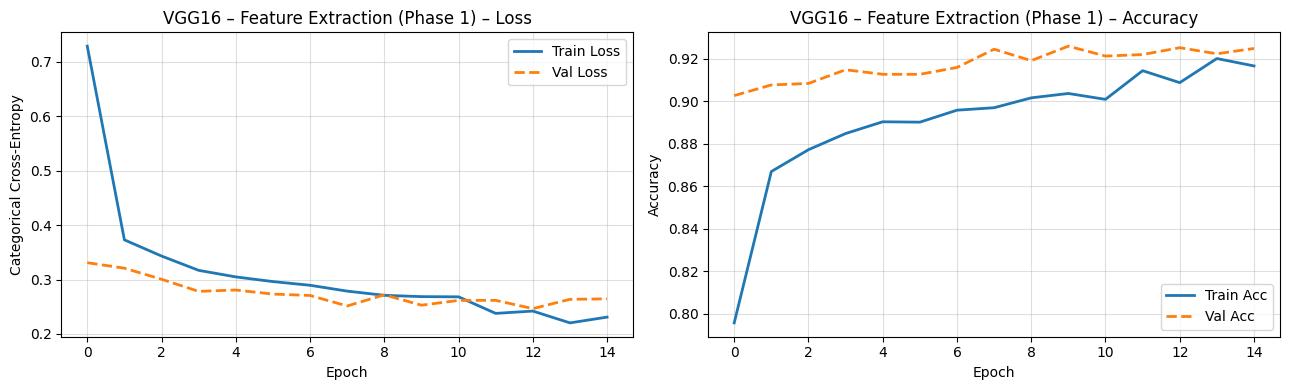

In [28]:
#  5.3  Phase 1: Feature extraction (frozen base)
# PDF §2.6.2: "Feature Extraction: Freeze convolutional base; train only new layers"

vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_vgg_phase1 = vgg_model.fit(
    train_ds_B, validation_data=val_ds_B, epochs=15,
    callbacks=[early_stop, lr_reduce], verbose=1
)
vgg_p1_time = time.time() - t0
print(f"\nVGG16 Phase 1 training time: {vgg_p1_time:.1f} s")

plot_history(history_vgg_phase1, title='VGG16 – Feature Extraction (Phase 1)',
             save_name='vgg_phase1_curves.png')

Layers trainable after Phase 2 setup:
  ✓ block5_conv1
  ✓ block5_conv2
  ✓ block5_conv3
  ✓ block5_pool
Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 168s 455ms/step - accuracy: 0.9185 - loss: 0.2309 - val_accuracy: 0.9213 - val_loss: 0.2741 - learning_rate: 1.0000e-05
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 154s 440ms/step - accuracy: 0.9282 - loss: 0.1969 - val_accuracy: 0.9292 - val_loss: 0.2363 - learning_rate: 1.0000e-05
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 150s 428ms/step - accuracy: 0.9309 - loss: 0.1856 - val_accuracy: 0.9260 - val_loss: 0.2466 - learning_rate: 1.0000e-05
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 154s 440ms/step - accuracy: 0.9435 - loss: 0.1597 - val_accuracy: 0.9324 - val_loss: 0.2511 - learning_rate: 1.0000e-05
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9426 - loss: 0.1558
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
350/350 ━━━━━━━━━━━━━━━━━━━━ 153s 438ms/step - accuracy: 0.9421 - loss: 0.1577 - val_accura

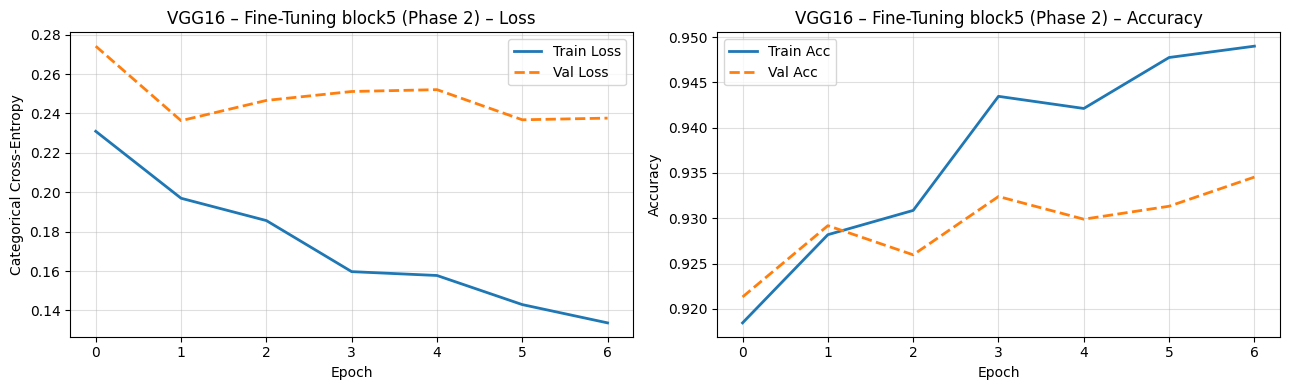

In [29]:
#  5.4  Phase 2: Fine-tune last VGG block (block5) ─
# PDF §2.6.2: "Unfreeze some convolutional layers; lower learning rate"
# Proposal §5.3: "Unfreeze final convolutional block at lower LR"

# Unfreeze block5 (last 4 conv layers of VGG16)
base_vgg.trainable = True
for layer in base_vgg.layers:
    layer.trainable = layer.name.startswith('block5')

print("Layers trainable after Phase 2 setup:")
for layer in base_vgg.layers:
    if layer.trainable:
        print(f"  ✓ {layer.name}")

# Recompile at much lower LR to avoid catastrophic forgetting
vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_vgg_phase2 = vgg_model.fit(
    train_ds_B, validation_data=val_ds_B, epochs=20,
    callbacks=[early_stop, lr_reduce], verbose=1
)
vgg_p2_time = time.time() - t0
print(f"\nVGG16 Phase 2 fine-tuning time: {vgg_p2_time:.1f} s")

plot_history(history_vgg_phase2, title='VGG16 – Fine-Tuning block5 (Phase 2)',
             save_name='vgg_phase2_curves.png')


  VGG16 Transfer Learning – Evaluation Results
  Test Loss     : 0.2286
  Test Accuracy : 0.9270 (92.70%)

Classification Report:
              precision    recall  f1-score   support

   buildings     0.9494    0.9016    0.9249       437
      forest     0.9874    0.9958    0.9916       474
     glacier     0.8764    0.8716    0.8740       553
    mountain     0.8836    0.8819    0.8827       525
         sea     0.9646    0.9627    0.9637       510
      street     0.9141    0.9561    0.9346       501

    accuracy                         0.9270      3000
   macro avg     0.9293    0.9283    0.9286      3000
weighted avg     0.9271    0.9270    0.9269      3000



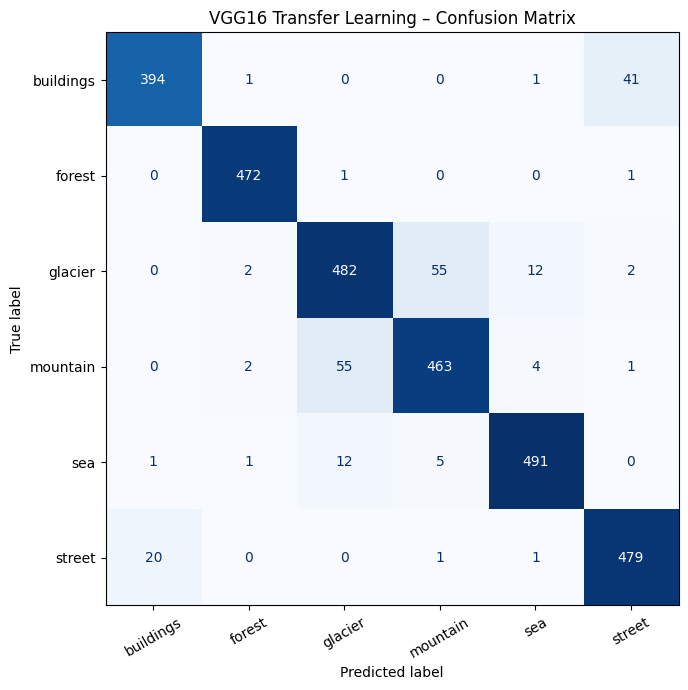

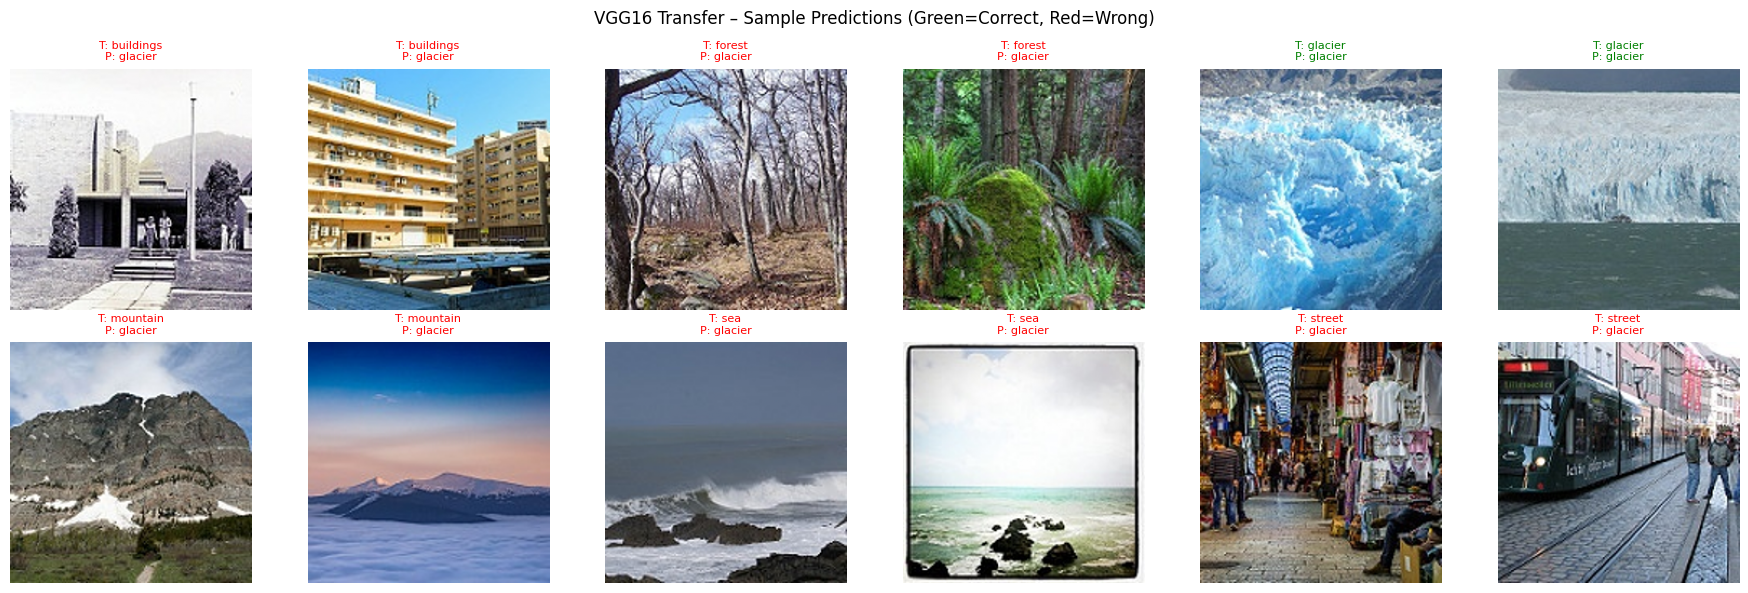

In [32]:
#  5.5  Evaluate VGG16
# PDF §2.6.3: "Evaluate fine-tuned model; compare with baseline and deeper models"

vgg_results = evaluate_model(vgg_model, test_ds_B, 'VGG16 Transfer Learning')
show_predictions(vgg_model, TEST_DIR, img_size=IMG_SIZE_B,
                 title='VGG16 Transfer')

---
## §6 · Final Summary & Report Tables
> **PDF §3 §6** – *"Experiments and Results; Fine-Tuning or Transfer Learning discussion."*

In [33]:
#  6.1  All-model summary table ─
vgg_total_time = vgg_p1_time + vgg_p2_time

all_results = [
    ('Baseline CNN',       baseline_results,    baseline_train_time,  'Adam'),
    ('Deeper – Adam',      deeper_adam_results, deeper_adam_time,     'Adam'),
    ('Deeper – SGD',       deeper_sgd_results,  deeper_sgd_time,      'SGD'),
    ('Ablation No-Drop',   ablation_results,    ablation_time,        'Adam'),
    ('VGG16 TL',           vgg_results,         vgg_total_time,       'Adam 1e-5'),
]

print(f"{'Model':<22} {'Optimizer':<12} {'Test Acc':>10} {'Test Loss':>10} {'Train Time':>12}")
print("-" * 72)
for name, res, t, opt in all_results:
    print(f"{name:<22} {opt:<12} {res['accuracy']:>10.4f} {res['loss']:>10.4f} {t:>10.1f}s")

print("\n[Key discussion points for report §6]")
print("  • Does VGG16 TL outperform from-scratch CNN? (Expected: Yes)")
print("  • Does deeper + regularisation beat baseline? (Expected: Yes if not overfitting)")
print("  • Adam vs SGD: which converges faster? (Expected: Adam)")
print("  • Ablation: confirms Dropout reduces val-train accuracy gap")
print("  • Glacier vs Mountain confusion: check confusion matrices")

Model                  Optimizer      Test Acc  Test Loss   Train Time
------------------------------------------------------------------------
Baseline CNN           Adam             0.8613     0.4047     1485.4s
Deeper – Adam          Adam             0.1707     4.1825      471.3s
Deeper – SGD           SGD              0.5877     1.0007      423.2s
Ablation No-Drop       Adam             0.1920     3.3239      426.5s
VGG16 TL               Adam 1e-5        0.9270     0.2286     3457.0s

[Key discussion points for report §6]
  • Does VGG16 TL outperform from-scratch CNN? (Expected: Yes)
  • Does deeper + regularisation beat baseline? (Expected: Yes if not overfitting)
  • Adam vs SGD: which converges faster? (Expected: Adam)
  • Ablation: confirms Dropout reduces val-train accuracy gap
  • Glacier vs Mountain confusion: check confusion matrices


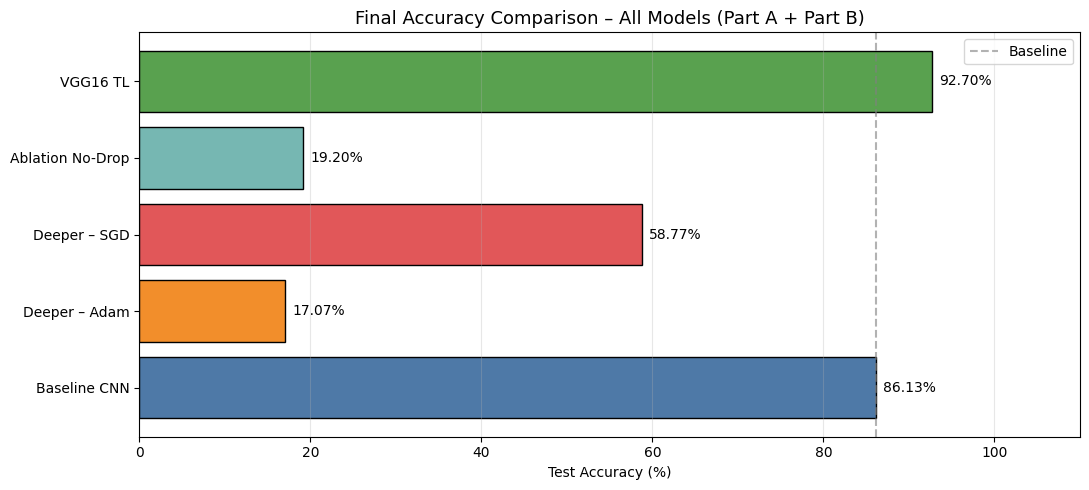

In [34]:
#  6.2  Final accuracy bar chart – all 5 models ─

model_names = [r[0] for r in all_results]
model_accs  = [r[1]['accuracy'] * 100 for r in all_results]
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(model_names, model_accs, color=colors, edgecolor='black')
ax.bar_label(bars, fmt='%.2f%%', padding=5, fontsize=10)
ax.set_xlim(0, 110)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Final Accuracy Comparison – All Models (Part A + Part B)', fontsize=13)
ax.axvline(x=model_accs[0], color='gray', linestyle='--', alpha=0.6, label='Baseline')
ax.legend()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('final_accuracy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [35]:
#  6.3  Requirements Traceability Matrix
# Quick self-check: every PDF requirement → notebook cell

rtm = [
    ('PDF §2.5.1', 'Data Understanding & EDA',            'Cell §1 (1.1–1.5)', '✓'),
    ('PDF §2.5.1', 'Augmentation visualisation',          'Cell §1.5',         '✓'),
    ('PDF §2.5.2', 'Baseline: 3 Conv + 3 FCN + output',   'Cell §2.1',         '✓'),
    ('PDF §2.5.2', 'Baseline training + loss curves',     'Cells §2.2–2.3',    '✓'),
    ('PDF §2.5.2', 'Metrics: Acc, Prec, Rec, F1',         'Cell §2.4',         '✓'),
    ('PDF §2.5.2', 'Inference on sample images',          'Cell §2.5',         '✓'),
    ('PDF §2.5.3', 'Deeper: ≥2× layers + BatchNorm+Drop', 'Cell §3.1',         '✓'),
    ('PDF §2.5.3', 'Compare deeper vs baseline',          'Cell §4',           '✓'),
    ('PDF §2.5.4', 'SGD vs Adam comparison',              'Cells §3.2–3.3',    '✓'),
    ('PDF §2.5.4', 'Ablation study',                      'Cell §3.4',         '✓'),
    ('PDF §2.5.4', 'Computational efficiency report',     'Cell §4.1',         '✓'),
    ('PDF §2.6.1', 'VGG16 loaded + head replaced',        'Cell §5.2',         '✓'),
    ('PDF §2.6.2', 'Feature extraction (frozen base)',     'Cell §5.3',         '✓'),
    ('PDF §2.6.2', 'Fine-tuning (unfreeze block5)',        'Cell §5.4',         '✓'),
    ('PDF §2.6.2', '224×224 resize for VGG16',            'Cell §5.1',         '✓'),
    ('PDF §2.6.3', 'TL evaluation + comparison',          'Cells §5.5, §6',    '✓'),
    ('PDF §2.5.5', 'GPU usage noted',                     'Cell §0',           '✓'),
    ('Proposal §5.1', 'Val split 80/20 from train',       'Cell §1.4',         '✓'),
    ('Proposal §5.2', 'Filters 32→64→128; ReLU; MaxPool', 'Cell §2.1',         '✓'),
    ('Proposal §5.3', 'VGG16 backbone',                   'Cell §5.2',         '✓'),
    ('Proposal §3.1', 'Corrupt image removal',            'Cell §1.1',         '✓'),
]

print(f"{'PDF/Proposal Ref':<18} {'Requirement':<42} {'Implemented In':<22} {'Status'}")
print("-" * 92)
for ref, req, cell, status in rtm:
    print(f"{ref:<18} {req:<42} {cell:<22} {status}")

covered = sum(1 for *_, s in rtm if s == '✓')
print(f"\n✓ {covered}/{len(rtm)} requirements implemented.")

PDF/Proposal Ref   Requirement                                Implemented In         Status
--------------------------------------------------------------------------------------------
PDF §2.5.1         Data Understanding & EDA                   Cell §1 (1.1–1.5)      ✓
PDF §2.5.1         Augmentation visualisation                 Cell §1.5              ✓
PDF §2.5.2         Baseline: 3 Conv + 3 FCN + output          Cell §2.1              ✓
PDF §2.5.2         Baseline training + loss curves            Cells §2.2–2.3         ✓
PDF §2.5.2         Metrics: Acc, Prec, Rec, F1                Cell §2.4              ✓
PDF §2.5.2         Inference on sample images                 Cell §2.5              ✓
PDF §2.5.3         Deeper: ≥2× layers + BatchNorm+Drop        Cell §3.1              ✓
PDF §2.5.3         Compare deeper vs baseline                 Cell §4                ✓
PDF §2.5.4         SGD vs Adam comparison                     Cells §3.2–3.3         ✓
PDF §2.5.4         Ablation stud

In [36]:
#  6.4  Save models ─

baseline_model.save('baseline_cnn.h5')
deeper_model.save('deeper_cnn_adam.h5')
vgg_model.save('vgg16_transfer.h5')
print("Models saved: baseline_cnn.h5 | deeper_cnn_adam.h5 | vgg16_transfer.h5")
print("\n[Colab Tip] Download to local machine:")
print("  from google.colab import files")
print("  files.download('vgg16_transfer.h5')")

Models saved: baseline_cnn.h5 | deeper_cnn_adam.h5 | vgg16_transfer.h5

[Colab Tip] Download to local machine:
  from google.colab import files
  files.download('vgg16_transfer.h5')


---
## README – Quick Start

```
# 1. Upload Scene_Classification.zip to Colab
#    (Files panel → Upload → select zip)

# 2. Make sure GPU is enabled:
#    Runtime → Change runtime type → T4 GPU

# 3. Run all cells in order:
#    Runtime → Run all  (or Ctrl+F9)

# 4. Plots are auto-saved as PNG in the working directory.

# 5. After execution review:
#    - class_distribution.png
#    - augmentation_examples.png
#    - baseline_curves.png / deeper_adam_curves.png
#    - confusion_*.png
#    - final_accuracy_comparison.png
#    - Requirements Traceability Matrix (last cell)

# Approximate wall-clock times on Colab T4 GPU:
#   Baseline (30 ep)     ~  4 min
#   Deeper Adam (40 ep)  ~ 10 min
#   Deeper SGD  (40 ep)  ~ 10 min
#   Ablation    (40 ep)  ~ 10 min
#   VGG16 Phase1+2       ~ 15 min
#   TOTAL                ~ 50 min
```

---
*6CS012 – Binaya Bohara (2418248) | Herald College Kathmandu | April 2026*